<a href="https://colab.research.google.com/github/timmyt110/CSCI_164_2025/blob/main/Problem_Solving_wSearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import heapq
import time
from collections import deque, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# Initialize

In [2]:
# Puzzle class that works for both 3x3 and 4x4
class Puzzle:
    __slots__ = ['board', 'size', 'goal']

    def __init__(self, board, size):
        self.board = board
        self.size = size
        self.goal = tuple(list(range(1, size*size)) + [0])

    def is_goal(self):
        return tuple(self.board) == self.goal

    def get_blank_pos(self):
        return self.board.index(0)

    def get_neighbors(self):
        neighbors = []
        blank = self.get_blank_pos()
        x, y = divmod(blank, self.size)
        directions = [(-1,0),(1,0),(0,-1),(0,1)]

        for dx, dy in directions:
            nx, ny = x+dx, y+dy
            if 0 <= nx < self.size and 0 <= ny < self.size:
                new_blank = nx*self.size + ny
                new_board = list(self.board)
                new_board[blank], new_board[new_blank] = new_board[new_blank], new_board[blank]
                neighbors.append(Puzzle(new_board, self.size))
        return neighbors
    def __hash__(self):
        return hash(tuple(self.board))

    def __eq__(self, other):
        return self.board == other.board

    def __lt__(self, other):
        return self.board < other.board


# Random Walk

In [3]:
# Random walk generator
def random_walk(start, steps):
    state = start
    for _ in range(steps):
        state = random.choice(state.get_neighbors())
    return state

# Heuristics
def out_of_place(state):
    return sum([1 if state.board[i] != 0 and state.board[i] != state.goal[i] else 0 for i in range(len(state.board))])

def manhattan(state):
    dist = 0
    for i, val in enumerate(state.board):
        if val == 0:
            continue
        x1, y1 = divmod(i, state.size)
        x2, y2 = divmod(val-1, state.size)
        dist += abs(x1 - x2) + abs(y1 - y2)
    return dist


# Breath First Search

In [4]:
# BFS with early exit limit
def bfs(start, max_nodes=100000):
    frontier = deque([start])
    came_from = {start: None}
    nodes_expanded = 0

    while frontier and nodes_expanded < max_nodes:
        current = frontier.popleft()
        nodes_expanded += 1

        if current.is_goal():
            return reconstruct_path(came_from, current), nodes_expanded

        for neighbor in current.get_neighbors():
            if neighbor not in came_from:
                frontier.append(neighbor)
                came_from[neighbor] = current

    return [], nodes_expanded


# AStar

In [5]:
# A*
def astar(start, heuristic):
    frontier = [(heuristic(start), 0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0}
    nodes_expanded = 0

    while frontier:
        _, cost, current = heapq.heappop(frontier)
        nodes_expanded += 1

        if current.is_goal():
            return reconstruct_path(came_from, current), nodes_expanded

        for neighbor in current.get_neighbors():
            new_cost = cost + 1
            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor)
                heapq.heappush(frontier, (priority, new_cost, neighbor))
                came_from[neighbor] = current

    return [], nodes_expanded


In [6]:
# Reconstruct path
def reconstruct_path(came_from, current):
    path = []
    while current:
        path.append(current)
        current = came_from[current]
    path.reverse()
    return path

# Test Problem

In [7]:
# Run experiments
def run_experiments(size):
    steps_list = [5, 10, 20, 40, 80]
    goal = Puzzle(list(range(1, size*size)) + [0], size)
    results = []

    for steps in steps_list:
        problems_per_step = 3 if size == 3 else 1
        for _ in range(problems_per_step):
            problem = random_walk(goal, steps)
            entry = {
                'size': size,
                'start': problem.board,
                'steps': steps
            }

            if size == 3 or steps <= 20:
                path_bfs, nodes_bfs = bfs(problem)
                entry['bfs_len'] = len(path_bfs)-1
                entry['bfs_nodes'] = nodes_bfs
            else:
                entry['bfs_len'] = None
                entry['bfs_nodes'] = None

            path_astar1, nodes_astar1 = astar(problem, out_of_place)
            entry['astar_oop_len'] = len(path_astar1)-1
            entry['astar_oop_nodes'] = nodes_astar1

            path_astar2, nodes_astar2 = astar(problem, manhattan)
            entry['astar_man_len'] = len(path_astar2)-1
            entry['astar_man_nodes'] = nodes_astar2

            results.append(entry)

    return results

# Result

In [8]:
# Display results as table and plot

def analyze_results(results):
    df = pd.DataFrame(results)
    print(df.head())

    group = df.groupby(['size', 'steps']).mean(numeric_only=True).reset_index()

    plt.figure(figsize=(14, 6))
    for alg in ['bfs_nodes', 'astar_oop_nodes', 'astar_man_nodes']:
        for size in sorted(df['size'].unique()):
            subset = group[group['size'] == size]
            label = f"{alg} (size={size}x{size})"
            plt.plot(subset['steps'], subset[alg], marker='o', label=label)

    plt.title("Nodes Expanded vs. Steps in Random Walk")
    plt.xlabel("Random Walk Steps")
    plt.ylabel("Average Nodes Expanded")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 3x3 Result + Graph

   size                        start  steps  bfs_len  bfs_nodes  \
0     3  [1, 2, 3, 4, 5, 6, 7, 0, 8]      5        1          4   
1     3  [1, 0, 3, 4, 2, 5, 7, 8, 6]      5        3         15   
2     3  [1, 2, 3, 0, 5, 6, 4, 7, 8]      5        3         13   
3     3  [1, 2, 3, 4, 5, 6, 0, 7, 8]     10        2          7   
4     3  [1, 3, 0, 4, 2, 6, 7, 5, 8]     10        4         25   

   astar_oop_len  astar_oop_nodes  astar_man_len  astar_man_nodes  
0              1                2              1                2  
1              3                4              3                4  
2              3                4              3                4  
3              2                3              2                3  
4              4                5              4                5  


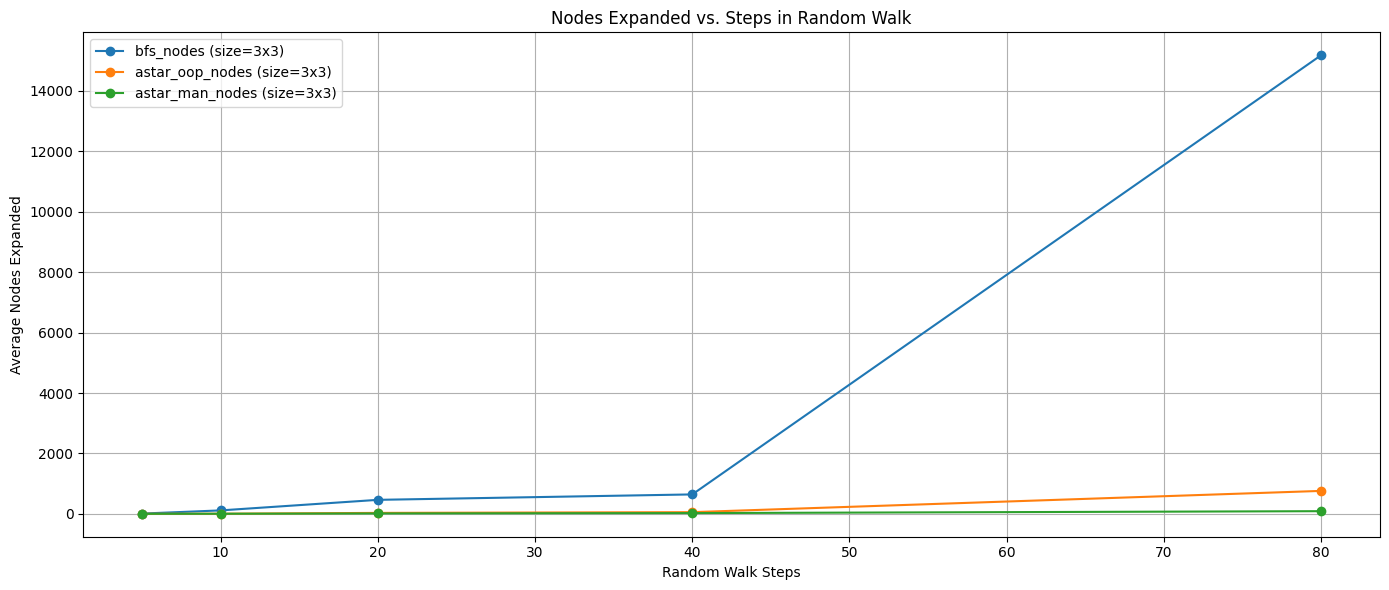

In [9]:
results_3x3 = run_experiments(3)
analyze_results(results_3x3)

# 4x4 Result + Graph

   size                                              start  steps  bfs_len  \
0     4  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...      5      1.0   
1     4  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0, 11, 13, 14,...     10      2.0   
2     4  [1, 2, 3, 4, 9, 5, 8, 0, 6, 14, 7, 12, 13, 11,...     20     12.0   
3     4  [1, 6, 2, 8, 9, 5, 4, 3, 10, 11, 14, 12, 13, 0...     40      NaN   
4     4  [2, 1, 3, 4, 6, 11, 5, 8, 0, 9, 7, 12, 13, 10,...     80      NaN   

   bfs_nodes  astar_oop_len  astar_oop_nodes  astar_man_len  astar_man_nodes  
0        4.0              1                2              1                2  
1       15.0              2                3              2                3  
2    16182.0             12               47             12               17  
3        NaN             18              588             18               51  
4        NaN             20             5945             20             1003  


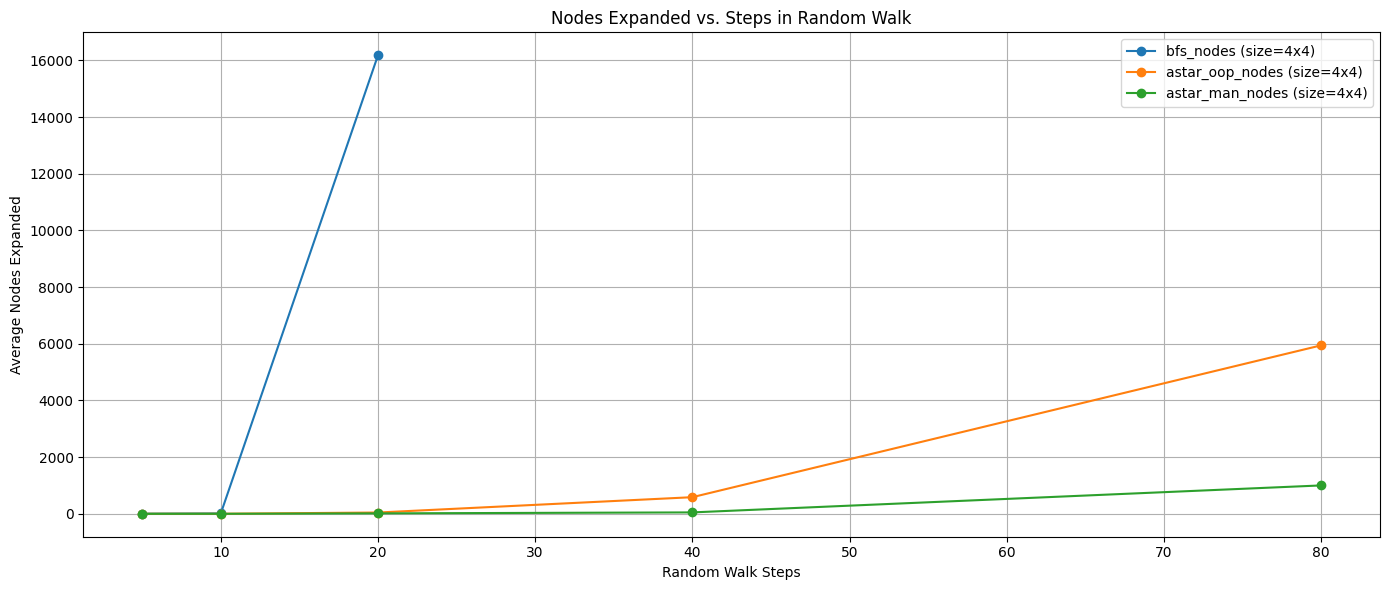

In [10]:
results_4x4 = run_experiments(4)
analyze_results(results_4x4)

# Explanation about result -> search as a tool for Artificial Intelligence

These results demonstrate the huge impact that growing problem size and complexity has on search-based Artificial Intelligence methods. In the 3x3 puzzle, both uninformed (BFS) and informed (A*) search algorithms perform well, with relatively short solution lengths and modest node growth, even with longer random walks. However, as the puzzle size rises to 4x4, the search area expands exponentially, and BFS becomes computationally infeasible for more complex problems—failing to yield results for 40- and 80-step walks due to excessive memory or time consumption. In contrast, A* search, especially when combined with the Manhattan Distance heuristic, continues to find solutions effectively while dramatically lowering the number of nodes expanded. This suggests that, while uninformed search may handle smaller or easier issues, informed search with heuristics becomes increasingly important as problem complexity increases. These results highlight the significance of heuristic design in AI, particularly for addressing real-world situations where exhaustive search is impossible.